# Talento Universitario

In [55]:
import pandas as pd
def egresados_to_parquet(file_path, ambitos_estudio, universidades_df, output_path):
    df = pd.read_csv(file_path, sep=';', dtype={'codigo_universidad': str})
    unis_df = universidades_df[['codigo', 'cmun', 'cpro', 'ccaa']].copy().rename(columns={'codigo': 'codigo_universidad'})
    codigos_unis = set(unis_df['codigo_universidad'].unique().tolist())
    nacional_df = df[(df['universidad'] == 'Todas las universidades') & df['ambito_de_estudio'].isin(ambitos_estudio)].copy()
    is_hombre = (nacional_df['sexo'] == 'Hombres')
    is_mujer = (nacional_df['sexo'] == 'Mujeres')
    is_ambos = (nacional_df['sexo'] == 'Ambos sexos')#is_hombre | is_mujer
    nacional_df['egresados'] = nacional_df['total']*is_ambos
    nacional_df['egresados_hombres'] = nacional_df['total']*is_hombre
    nacional_df['egresados_mujeres'] = nacional_df['total']*is_mujer
    egresados_nacional_df = nacional_df.groupby(['universidad', 'ambito_de_estudio', 'grupo_de_edad', 'ano']).agg({
        'egresados': 'sum', 
        'egresados_hombres': 'sum', 
        'egresados_mujeres': 'sum'
    }).reset_index()
    egresados_nacional_df['codigo_universidad'] = '000'

    universidad_df = df[df['codigo_universidad'].isin(codigos_unis) & df['ambito_de_estudio'].isin(ambitos_estudio)].copy()
    is_hombre = (universidad_df['sexo'] == 'Hombres')
    is_mujer = (universidad_df['sexo'] == 'Mujeres')
    is_ambos = (universidad_df['sexo'] == 'Ambos sexos')#is_hombre | is_mujer
    universidad_df['egresados'] = universidad_df['total']*is_ambos
    universidad_df['egresados_hombres'] = universidad_df['total']*is_hombre
    universidad_df['egresados_mujeres'] = universidad_df['total']*is_mujer
    egresados_universidad_df = universidad_df.groupby(
        ['codigo_universidad', 'universidad', 'ambito_de_estudio', 'grupo_de_edad', 'ano']).agg({
            'egresados': 'sum',
            'egresados_hombres': 'sum',
            'egresados_mujeres': 'sum'
        }).reset_index()
    egresados_df = pd.concat([egresados_universidad_df, egresados_nacional_df], ignore_index=True).rename(
        columns={'ano': 'anno', 'total': 'egresados'})
    egresados_df = pd.merge(egresados_df, unis_df,
                            on='codigo_universidad', how='left')
    egresados_df.to_parquet(
        output_path,
        index=False,
        compression='snappy',
        engine='pyarrow'
    )
    return egresados_df

stem = ['Informática', 'Ingenierías', 'Matemáticas y Estadística', 'Ciencias Físicas, químicas, geológicas','Ciencias de la vida','Arquitectura y construcción']
salud = ['Medicina', 'Enfermería y atención a enfermos','Otras ciencias de la Salud']
negocios_derecho = ['Administración y gestión de empresas', 'Derecho', 'Otra Educación comercial y empresarial']

ambitos_estudio = ['Total'] + stem + salud + negocios_derecho
universidades_df = pd.read_csv('../data/processed/universidades_arc_gis.csv',
                               sep=';', dtype={'codigo': str, 'cmun': str, 'cpro': str, 'ccaa': str})
grados_df = egresados_to_parquet(
    file_path="../data/processed/egresados_grado_universidades_2021_2024.csv",
    ambitos_estudio=ambitos_estudio,
    universidades_df=universidades_df,
    output_path="../data/golden/egresados_grados_2021_2024.parquet"
)
masteres_df = egresados_to_parquet(
    file_path="../data/processed/egresados_master_universidades_2021_2024.csv",
    ambitos_estudio=ambitos_estudio,
    universidades_df=universidades_df,
    output_path="../data/golden/egresados_master_2021_2024.parquet"
)
doctorados_df = egresados_to_parquet(
    file_path="../data/processed/egresados_doctorado_universidades_2021_2024.csv",
    ambitos_estudio=ambitos_estudio,
    universidades_df=universidades_df,
    output_path="../data/golden/egresados_doctorado_2021_2024.parquet"
)

In [56]:
import duckdb

def query(query_str):
    return duckdb.query(query_str).to_df()


TOP_PROVINCES_BY_GRADUATES = """
    SELECT 
        cpro,
        ambito_de_estudio,
        SUM(egresados) AS total_egresados,
        SUM(egresados_hombres) AS total_egresados_hombres,
        SUM(egresados_mujeres) AS total_egresados_mujeres
    FROM {df} 
    WHERE 
        anno = 2024 
        AND codigo_universidad != '000' 
        AND ambito_de_estudio != 'Total' 
        AND grupo_de_edad = 'Total'
    GROUP BY 
        cpro,
        ambito_de_estudio
    QUALIFY ROW_NUMBER() OVER (PARTITION BY ambito_de_estudio ORDER BY SUM(egresados) DESC) = 1
    ORDER BY 
        cpro ASC;
"""


def get_top_provinces_by_graduates(df):
    return query(TOP_PROVINCES_BY_GRADUATES.format(df=df))


PIVOT_STUDY_FIELD = """
    PIVOT (
        -- 1. Select the base data you want to work with
        SELECT 
            cpro,
            ambito_de_estudio,
            egresados
        FROM {df} 
        WHERE anno BETWEEN {start_year} AND {end_year}
          AND codigo_universidad != '000' 
          AND ambito_de_estudio != 'Total' 
          AND grupo_de_edad = 'Total'
    ) 
    -- 2. Define the column that will become the new headers
    ON ambito_de_estudio 

    -- 3. Define the aggregation to fill the new cells
    USING SUM(egresados)

    -- 4. Define the rows that will group the data
    GROUP BY 
        cpro
    ORDER BY 
        cpro;
"""


def get_pivot_study_field(df, start_year=2021, end_year=2024):
    return query(
            PIVOT_STUDY_FIELD.format(df=df, start_year=start_year, end_year=end_year)
        ).merge(
            query(
                """
                    SELECT 
                        cpro,
                        SUM(egresados) as Total
                    FROM {df}
                    WHERE anno BETWEEN {start_year} AND {end_year}
                        AND codigo_universidad != '000' 
                        AND ambito_de_estudio == 'Total' 
                        AND grupo_de_edad = 'Total'
                    GROUP BY cpro
                    ORDER BY cpro;
                """.format(df=df, start_year=start_year, end_year=end_year)
            ), on='cpro', how='left'
        )



In [57]:
empresas_df = pd.read_parquet("../data/processed/iberinform_startups_certificadas.parquet", engine='pyarrow')
municipios_df = pd.read_csv("../data/processed/municipios.csv", sep=",", dtype=str)
municipios_df['cmun'] = municipios_df['cpro']+municipios_df['cmun']
dict_municipios_cmun = municipios_df.set_index('nombre')['cmun'].to_dict()
dict_cpro_ccaa = municipios_df.drop_duplicates('cpro').set_index('cpro')['codauto'].to_dict()
empresas_df['anno_constitucion'] = pd.to_datetime(
    empresas_df['fecha_constitucion'], errors='coerce').dt.year
empresas_df['cmun'] = empresas_df['municipio'].map(dict_municipios_cmun)
empresas_df['cpro'] = empresas_df['cmun'].str[:2]
empresas_df['ccaa'] = empresas_df['cpro'].map(dict_cpro_ccaa)
provincia_startups_df = query(
    """
    PIVOT (
    -- 1. Preparamos los datos filtrados y calculamos el total por provincia
    SELECT 
        cpro,
        grupo_cnae,
        COUNT(*) OVER (PARTITION BY provincia) AS startups
    FROM empresas_df 
    WHERE anno_constitucion BETWEEN 2021 AND 2024
) 
-- 2. Definimos que los nombres de las columnas serán los grupos CNAE
ON grupo_cnae 

-- 3. La métrica a contar es el número de startups por cada cruce
USING COUNT(*) 

-- 4. Agrupamos por provincia y mantenemos el total que calculamos antes
GROUP BY 
    cpro,
    startups
ORDER BY 
    startups DESC;
    """).sort_values('cpro').reset_index(drop=True)

In [58]:
top10_grupos = query(
    """
        SELECT grupo_cnae, descripcion_grupo_cnae, COUNT(*) AS total_startups
        FROM empresas_df
        WHERE anno_constitucion BETWEEN 2021 AND 2024
        GROUP BY grupo_cnae, descripcion_grupo_cnae
        ORDER BY COUNT(*) DESC
        LIMIT 10;
    """
).set_index('descripcion_grupo_cnae')['grupo_cnae'].to_dict()

In [59]:
query(
    """
        SELECT grupo_cnae, descripcion_grupo_cnae, COUNT(*) AS total_startups
        FROM empresas_df
        WHERE anno_constitucion BETWEEN 2021 AND 2024
        GROUP BY grupo_cnae, descripcion_grupo_cnae
        ORDER BY COUNT(*) DESC
        LIMIT 10;
    """
)

,grupo_cnae,descripcion_grupo_cnae,total_startups
0,62,"Programación, consultoría y otras actividades ...",455
1,71,Servicios técnicos de arquitectura e ingenierí...,86
2,47,Comercio al por menor,80
3,72,Investigación y desarrollo,74
4,70,Actividades de las sedes centrales y consultor...,71
5,46,Comercio al por mayor,67
6,73,"Actividades de publicidad, estudios de mercado...",51
7,85,Educación,39
8,74,"Otras actividades profesionales, científicas y...",29
9,10,Industria alimentaria,25


## Grados

In [60]:
import pandas as pd

grados_df = pd.read_parquet("../data/golden/egresados_grados_2021_2024.parquet", engine='pyarrow')
provincia_grados_df = get_pivot_study_field('grados_df', start_year=2021, end_year=2024)
poblacion_2024_df = pd.read_parquet("../data/processed/poblacion_2024.parquet", engine='pyarrow')
poblacion_provincial_2024_df = poblacion_2024_df.groupby(['cpro','provincia']).agg(
    poblacion=('poblacion', 'sum'),
    hombres=('hombres', 'sum'),
    mujeres=('mujeres', 'sum')
).sort_values('cpro').reset_index()
provincia_startups_grados_df = pd.merge(poblacion_provincial_2024_df, provincia_startups_df, on='cpro', how='left').copy()
provincia_startups_grados_df = pd.merge(provincia_startups_grados_df, provincia_grados_df, on='cpro', how='left').copy()
provincia_startups_grados_df =provincia_startups_grados_df.fillna(0, inplace=True)

In [61]:
nacional = grados_df.query("universidad == 'Todas las universidades' and ambito_de_estudio == 'Total' and grupo_de_edad == 'Total'")

print("estadísticos de universitarios nacional: medias y varianzas anuales:")
print(f"Media: {nacional['egresados'].mean()}")
print(f"Varianza: {nacional['egresados'].std()**2}")

estadísticos de universitarios nacional: medias y varianzas anuales:
Media: 203313.25
Varianza: 13863732.916666666


In [62]:
print("estadísticos de universitarios generados entre 2021 y 2024, medias y varianzas provinciales:")
print(f"Media: {provincia_grados_df['Total'].mean()}")
print(f"Varianza: {provincia_grados_df['Total'].std()**2}")

estadísticos de universitarios generados entre 2021 y 2024, medias y varianzas provinciales:
Media: 21401.394736842107
Varianza: 1199965371.4345663


### Densidad empresas y densidad graduados

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    #'text.usetex': True,
    'pgf.rcfonts': False,   # Fuente con serifa para coherencia con el texto
    "font.size": 11,          # Tamaño base
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    #"axes.titleweight": "bold",
    "grid.alpha": 0.1         # Rejilla más sutil
})

# --- EJEMPLO DE USO ---

# # Definimos las columnas que quieres comparar (ajusta los nombres a tus datos reales)
# col_graduados = 'total_egresados/100K hab '  # Nombre exacto de tu columna normalizada
# col_startups = '(total_startups_provincia) total provincia' # Tu columna de densidad

# df_agregado = provincia_startups_grados_df.copy()
# df_agregado[col_graduados] = (df_agregado['Total'] / df_agregado['poblacion']) * 100000
# df_agregado[col_startups] = df_agregado['startups']/df_agregado['poblacion'] * 100000
# col_graduado_stem = 'stem/100K hab '
# df_agregado[col_graduado_stem] = (df_agregado[stem].sum(axis=1) / df_agregado['poblacion']) * 100000
# col_startups_informaticas = 'startups_informaticas/100K hab'
# df_agregado[col_startups_informaticas] = (df_agregado['62'] / df_agregado['poblacion']) * 100000

# col_startups_73 = 'startups_serivicos_arquitectura/100K hab'
# col_graduado_ingenieria = 'ingenierias/100K hab'
# df_agregado[col_startups_73] = (df_agregado['71'] / df_agregado['poblacion']) * 100000
# df_agregado[col_graduado_ingenieria] = (df_agregado['Ingenierías'] / df_agregado['poblacion']) * 100000

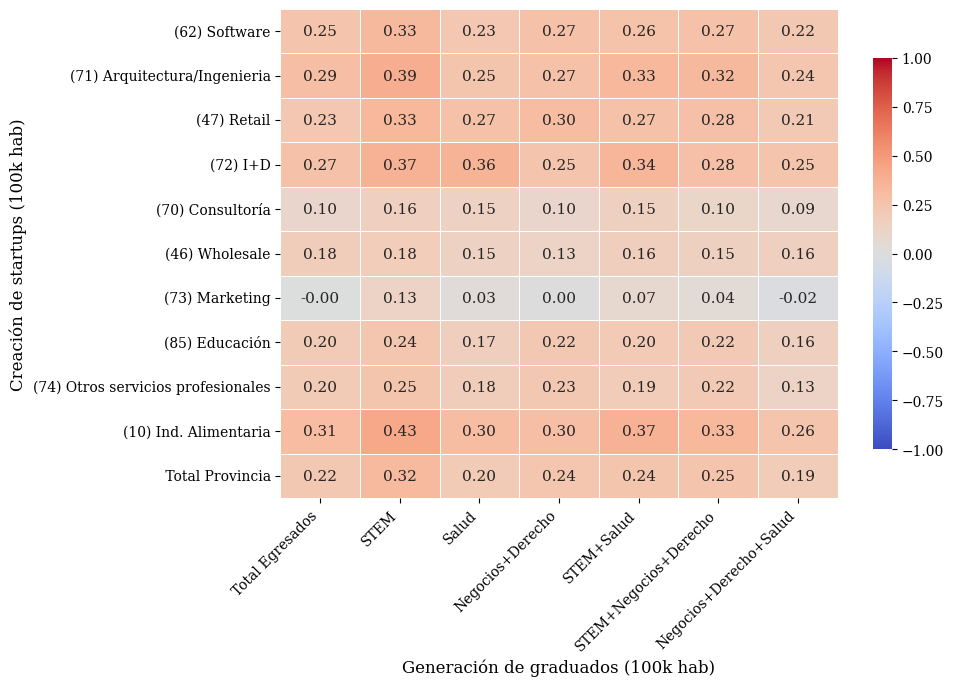

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DE CATEGORÍAS (Configuración centralizada)
CATEGORIAS_ESTUDIO = {
    'STEM': [
        'Informática', 'Ingenierías', 'Matemáticas y Estadística', 
        'Ciencias Físicas, químicas, geológicas', 'Ciencias de la vida', 
        'Arquitectura y construcción'
    ],
    'Salud': [
        'Medicina', 'Enfermería y atención a enfermos', 'Otras ciencias de la Salud'
    ],
    'Negocios+Derecho': [
        'Administración y gestión de empresas', 'Derecho', 
        'Otra Educación comercial y empresarial'
    ]
}

def preparar_datos(df_raw, sectores_startup, desagregado=False):
    """
    Limpia y normaliza los datos. 
    Graduados: Especialización (% sobre el total de la provincia)
    Startups: Densidad (Tasas por 100k hab)
    """
    df = df_raw.copy()
    
    # Listas de columnas según el modo
    all_grad_fields = [item for sublist in CATEGORIAS_ESTUDIO.values() for item in sublist]
    
    # A. Procesamiento de Graduados (Especialización %)
    if not desagregado:
        # Creamos las agregaciones
        for cat, cols in CATEGORIAS_ESTUDIO.items():
            df[cat] = df[cols].sum(axis=1)
        # Combinaciones específicas
        df['STEM+Salud'] = df['STEM'] + df['Salud']
        df['STEM+Negocios+Derecho'] = df['STEM'] + df['Negocios+Derecho']
        df['Negocios+Derecho+Salud'] = df['Negocios+Derecho'] + df['Salud']
        grad_cols_to_use = ['Total'] + list(CATEGORIAS_ESTUDIO.keys()) + ['STEM+Salud', 'STEM+Negocios+Derecho', 'Negocios+Derecho+Salud']
    else:
        grad_cols_to_use = ['Total'] + all_grad_fields

    # Nota: El Total se queda como tasa por 100k para ver volumen
    df_norm = pd.DataFrame(index=df.index)
    df_norm['Total Egresados'] = (df['Total'] / df['poblacion']) * 100000
    egr_cols  = ['Total Egresados']
    for col in grad_cols_to_use:
        if col != 'Total':
            df_norm[f'{col}'] = (df[col] / df['poblacion']) * 100000
            egr_cols.append(f'{col}')

    # B. Procesamiento de Startups (Densidad por 100k hab)
    startup_cols = []
    label_dict = { 
        '46':'Wholesale',
        '47': 'Retail',
        '62' : 'Software',
        '10':'Ind. Alimentaria',
        '70': 'Consultoría',
        '71':'Arquitectura/Ingenieria',
        '72':'I+D',
        '73':'Marketing',
        '74':'Otros servicios profesionales',
        '85':'Educación'
    }
    for name, code in sectores_startup.items():
        if code in df.columns:
            hint = f"({code})" if len(code) == 2 else ''
            col_name = f'{hint} {label_dict.get(code, name[:25])}'
            df_norm[col_name] = (df[code] / df['poblacion']) * 100000
            startup_cols.append(col_name)
            
    return df_norm, egr_cols, startup_cols

def plot_correlation(df_norm, grad_cols,xlabel, startup_cols,ylabel, title, save_as=None):
    """Genera el heatmap optimizado"""
    corr = df_norm[startup_cols + grad_cols].corr(method='spearman').loc[startup_cols, grad_cols]
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, 
                fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})
    
    plt.title(title, fontsize=16, pad=20)
    plt.ylabel(ylabel, fontsize=12)
    plt.xlabel(xlabel, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, format='pdf', pad_inches=0.1)
    plt.show()

# --- EJECUCIÓN ---

# Definir sectores (usando tus variables top10_grupos)
mis_sectores = top10_grupos.copy()
mis_sectores['Total Provincia'] = 'startups'

# 1. ANÁLISIS AGREGADO
df_agregado, g_cols, s_cols = preparar_datos(provincia_startups_grados_df, mis_sectores, desagregado=False)
plot_correlation(df_agregado, g_cols, "Generación de graduados (100k hab)", s_cols, "Creación de startups (100k hab)", "", save_as="../docs/manuscrito/recursos/figuras/corr-grados.pdf")

## Master

In [37]:
import pandas as pd
masteres_df = pd.read_parquet("../data/golden/egresados_master_2021_2024.parquet", engine='pyarrow')
provincia_masteres_df = get_pivot_study_field('masteres_df', start_year=2021, end_year=2024)
poblacion_2024_df = pd.read_parquet("../data/processed/poblacion_2024.parquet", engine='pyarrow')
poblacion_provincial_2024_df = poblacion_2024_df.groupby(['cpro']).agg(
    poblacion=('poblacion', 'sum'),
    hombres=('hombres', 'sum'),
    mujeres=('mujeres', 'sum') 
).reset_index()
provincia_startups_masteres_df = pd.merge(poblacion_provincial_2024_df, provincia_startups_df, on='cpro', how='left').copy()
provincia_startups_masteres_df = pd.merge(provincia_startups_masteres_df, provincia_masteres_df, on='cpro', how='left').copy()
provincia_startups_masteres_df =provincia_startups_masteres_df.fillna(0, inplace=True)


In [38]:
nacional = masteres_df.query("universidad == 'Todas las universidades' and ambito_de_estudio == 'Total' and grupo_de_edad == 'Total'")

print("estadísticos de universitarios nacional: medias y varianzas anuales:")
print(f"Media: {nacional['egresados'].mean()}")
print(f"Varianza: {nacional['egresados'].std()**2}")
print("estadísticos de masteres generados entre 2021 y 2024, medias y varianzas provinciales:")
print(f"Media: {provincia_masteres_df['Total'].mean()}")
print(f"Varianza: {provincia_masteres_df['Total'].std()**2}")

estadísticos de universitarios nacional: medias y varianzas anuales:
Media: 147594.5
Varianza: 123423739.66666669
estadísticos de masteres generados entre 2021 y 2024, medias y varianzas provinciales:
Media: 15536.263157894737
Varianza: 887074352.0369842


In [39]:
# Definimos las columnas que quieres comparar (ajusta los nombres a tus datos reales)
col_graduados = 'total_egresados/100K hab '  # Nombre exacto de tu columna normalizada
col_startups = '(total_startups_provincia) total provincia' # Tu columna de densidad

df_agregado = provincia_startups_masteres_df.copy()
df_agregado[col_graduados] = (df_agregado['Total'] / df_agregado['poblacion']) * 100000
df_agregado[col_startups] = df_agregado['startups']/df_agregado['poblacion'] * 100000
col_graduado_stem = 'stem/100K hab '
df_agregado[col_graduado_stem] = (df_agregado[stem].sum(axis=1) / df_agregado['poblacion']) * 100000
col_startups_informaticas = 'startups_informaticas/100K hab'
df_agregado[col_startups_informaticas] = (df_agregado['62'] / df_agregado['poblacion']) * 100000

col_startups_73 = 'startups_serivicos_arquitectura/100K hab'
col_graduado_ingenieria = 'ingenierias/100K hab'
df_agregado[col_startups_73] = (df_agregado['71'] / df_agregado['poblacion']) * 100000
df_agregado[col_graduado_ingenieria] = (df_agregado['Ingenierías'] / df_agregado['poblacion']) * 100000

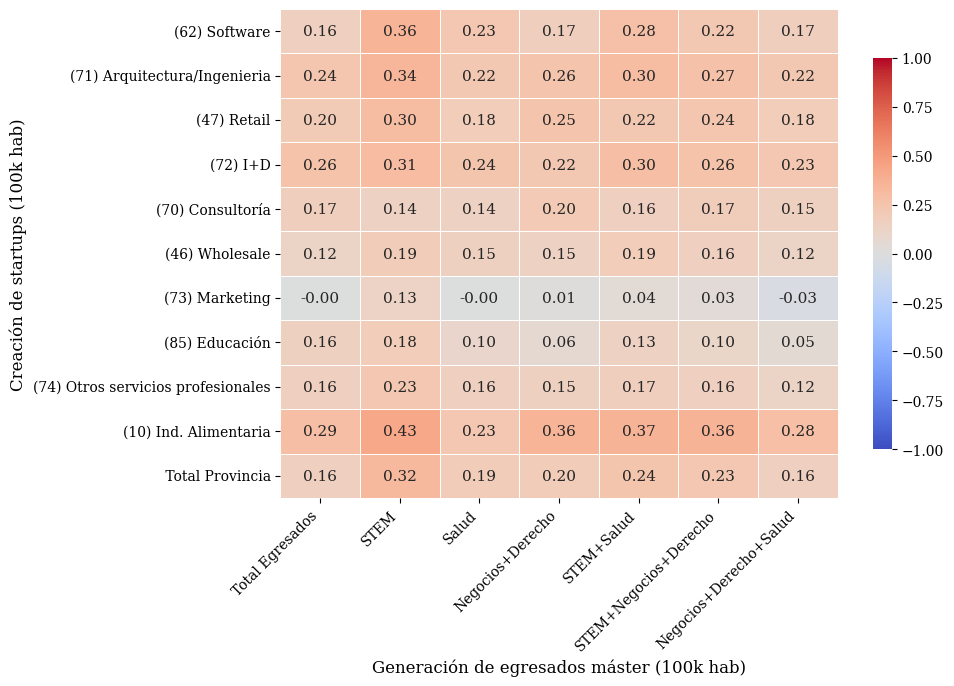

In [72]:
# --- EJECUCIÓN ---

# Definir sectores (usando tus variables top10_grupos)
mis_sectores = top10_grupos.copy()
mis_sectores['Total Provincia'] = 'startups'

# 1. ANÁLISIS AGREGADO
df_agregado, g_cols, s_cols = preparar_datos(provincia_startups_masteres_df, mis_sectores, desagregado=False)
plot_correlation(df_agregado, g_cols, "Generación de egresados máster (100k hab)", s_cols, "Creación de startups (100k hab)", "", save_as="../docs/manuscrito/recursos/figuras/corr-masteres.pdf")


## Doctorado

In [41]:
import pandas as pd
doctorados_df = pd.read_parquet("../data/golden/egresados_doctorado_2021_2024.parquet", engine='pyarrow')
provincia_doctorados_df = get_pivot_study_field('doctorados_df', start_year=2021, end_year=2024)

provincia_startups_doctorados_df = pd.merge(provincia_startups_df, provincia_doctorados_df, on='cpro', how='left').copy()

poblacion_2024_df = pd.read_parquet("../data/processed/poblacion_2024.parquet", engine='pyarrow')
poblacion_provincial_2024_df = poblacion_2024_df.groupby(['cpro']).agg(
    poblacion=('poblacion', 'sum'),
    hombres=('hombres', 'sum'),
    mujeres=('mujeres', 'sum') 
).reset_index()
provincia_startups_doctorados_df = pd.merge(poblacion_provincial_2024_df, provincia_startups_df, on='cpro', how='left').copy()
provincia_startups_doctorados_df = pd.merge(provincia_startups_doctorados_df, provincia_doctorados_df, on='cpro', how='left').copy()
provincia_startups_doctorados_df =provincia_startups_doctorados_df.fillna(0, inplace=True)

In [42]:
print("estadísticos de doctorados generados entre 2021 y 2024, medias y varianzas provinciales:")
print(f"Media: {provincia_doctorados_df['Total'].mean()}")
print(f"Varianza: {provincia_doctorados_df['Total'].std()**2}")

estadísticos de doctorados generados entre 2021 y 2024, medias y varianzas provinciales:
Media: 1253.0
Varianza: 4162437.3888888885


In [43]:
# Definimos las columnas que quieres comparar (ajusta los nombres a tus datos reales)
col_graduados = 'total_egresados/100K hab '  # Nombre exacto de tu columna normalizada
col_startups = '(total_startups_provincia) total provincia' # Tu columna de densidad

df_agregado = provincia_startups_doctorados_df.copy()
df_agregado[col_graduados] = (df_agregado['Total'] / df_agregado['poblacion']) * 100000
df_agregado[col_startups] = df_agregado['startups']/df_agregado['poblacion'] * 100000
col_graduado_stem = 'stem/100K hab '
df_agregado[col_graduado_stem] = (df_agregado[stem].sum(axis=1) / df_agregado['poblacion']) * 100000
col_startups_informaticas = 'startups_informaticas/100K hab'
df_agregado[col_startups_informaticas] = (df_agregado['62'] / df_agregado['poblacion']) * 100000

col_startups_72 = 'startups_I+D/100K hab'
col_graduado_ciencias_fisica_quimicas_geologicas = 'fisicas_quimicas_geologicas/100K hab'
df_agregado[col_startups_72] = (df_agregado['72'] / df_agregado['poblacion']) * 100000
df_agregado[col_graduado_ciencias_fisica_quimicas_geologicas] = (df_agregado['Ciencias Físicas, químicas, geológicas'] / df_agregado['poblacion']) * 100000
col_graduado_ciencias_vida = 'ciencias_vida/100K hab'
df_agregado[col_startups_72] = (df_agregado['72'] / df_agregado['poblacion']) * 100000
df_agregado[col_graduado_ciencias_vida] = (df_agregado['Ciencias de la vida'] / df_agregado['poblacion']) * 100000
col_graduado_ingenierias = 'ingenierias/100K hab'
df_agregado[col_graduado_ingenierias] = (df_agregado['Ingenierías'] / df_agregado['poblacion']) * 100000
col_graduado_medicina = 'medicina/100K hab'
df_agregado[col_graduado_medicina] = (df_agregado['Medicina'] / df_agregado['poblacion']) * 100000

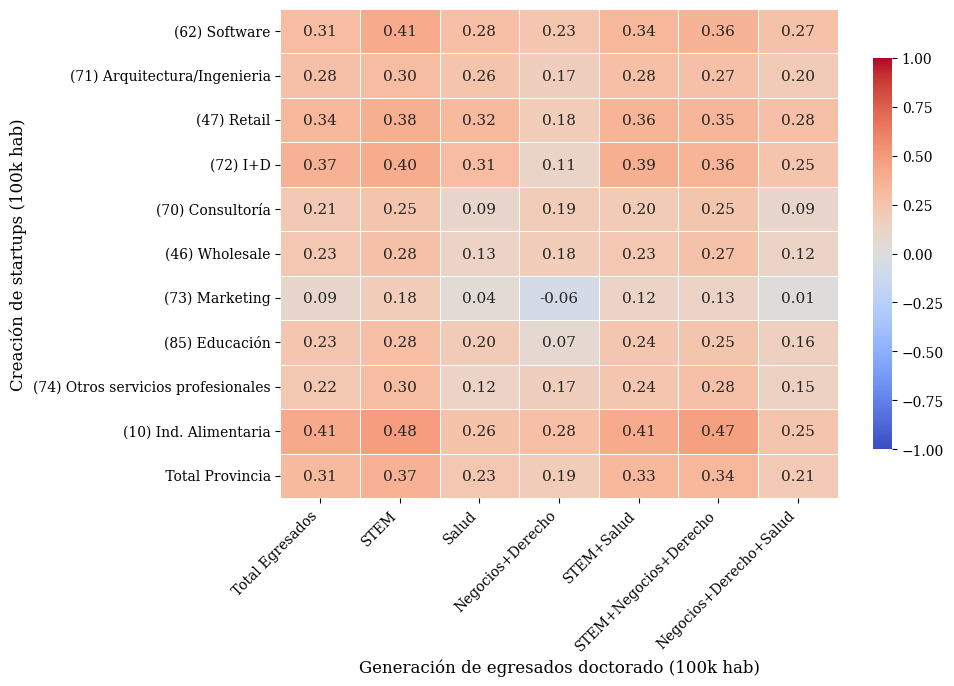

In [68]:
mis_sectores = top10_grupos.copy()
mis_sectores['Total Provincia'] = 'startups'

# 1. ANÁLISIS AGREGADO
df_agregado, g_cols, s_cols = preparar_datos(provincia_startups_doctorados_df, mis_sectores, desagregado=False)
plot_correlation(df_agregado, g_cols, "Generación de egresados doctorado (100k hab)", s_cols, "Creación de startups (100k hab)", "", save_as="../docs/manuscrito/recursos/figuras/corr-doctorados.pdf")

# Mapas de egresados universitarios por provincia

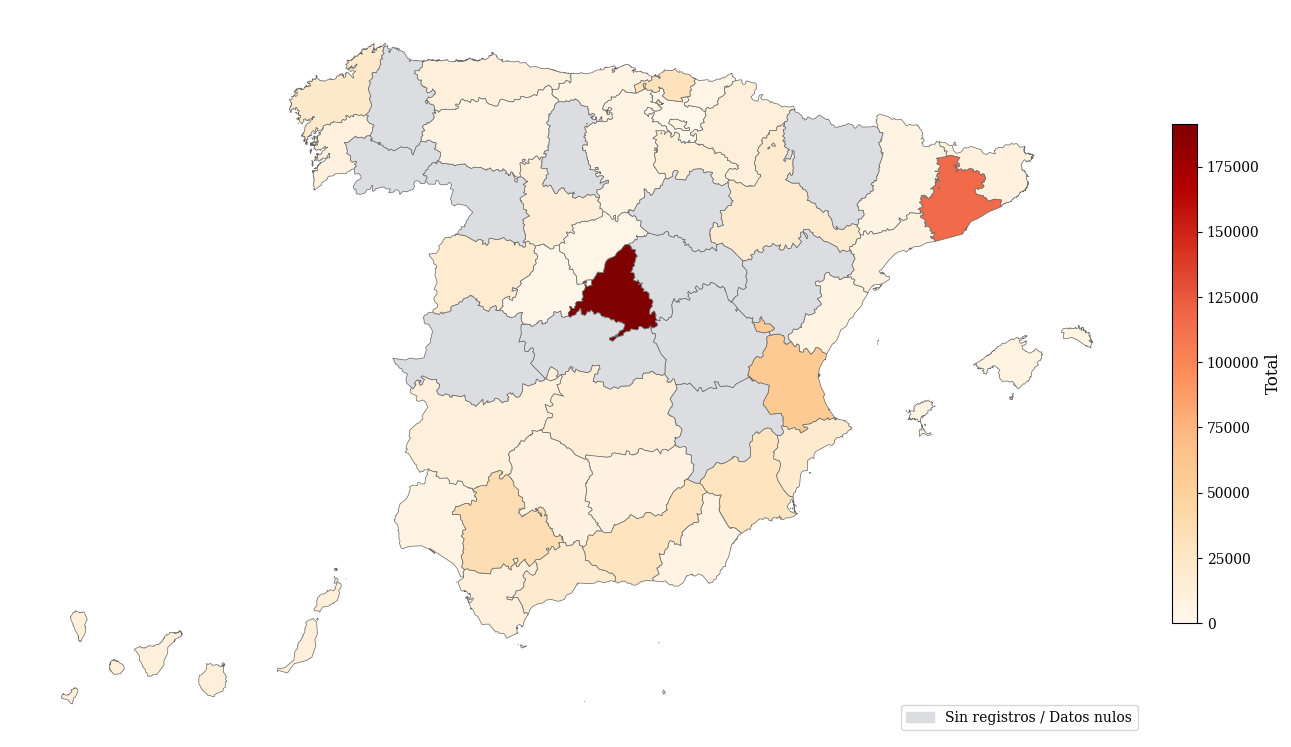

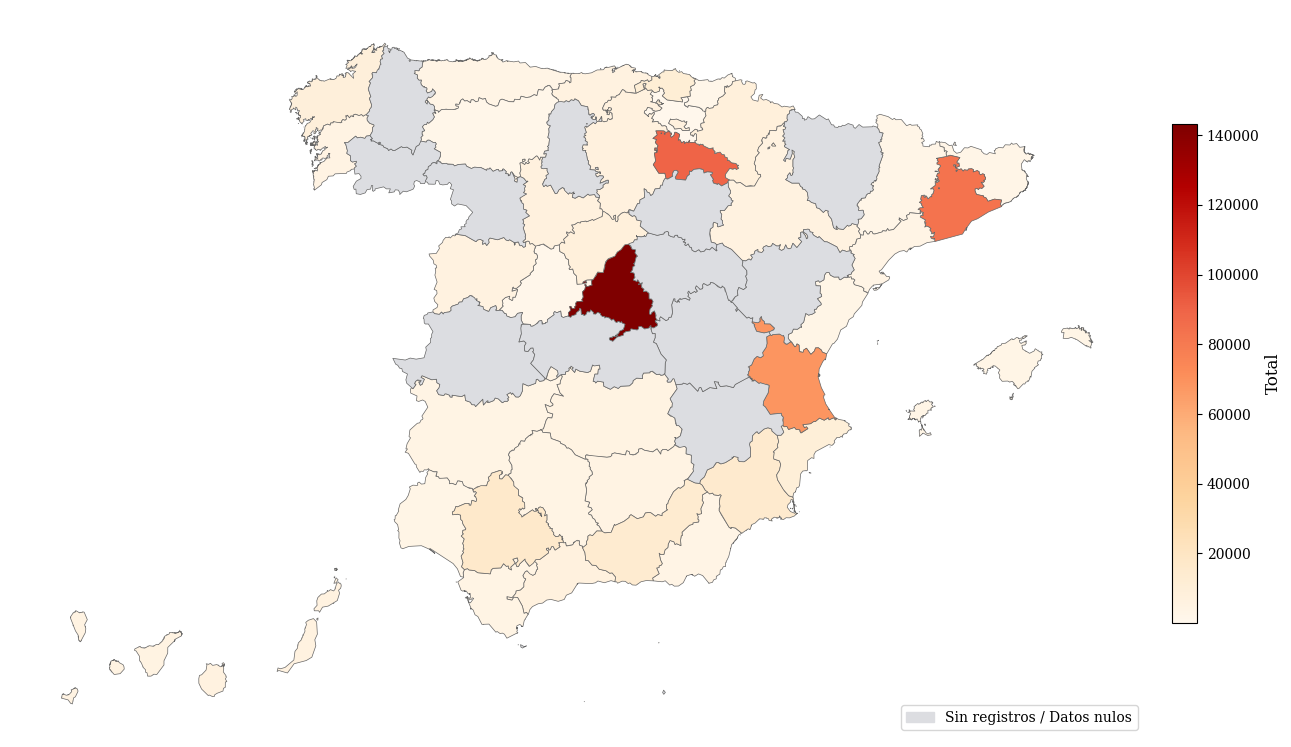

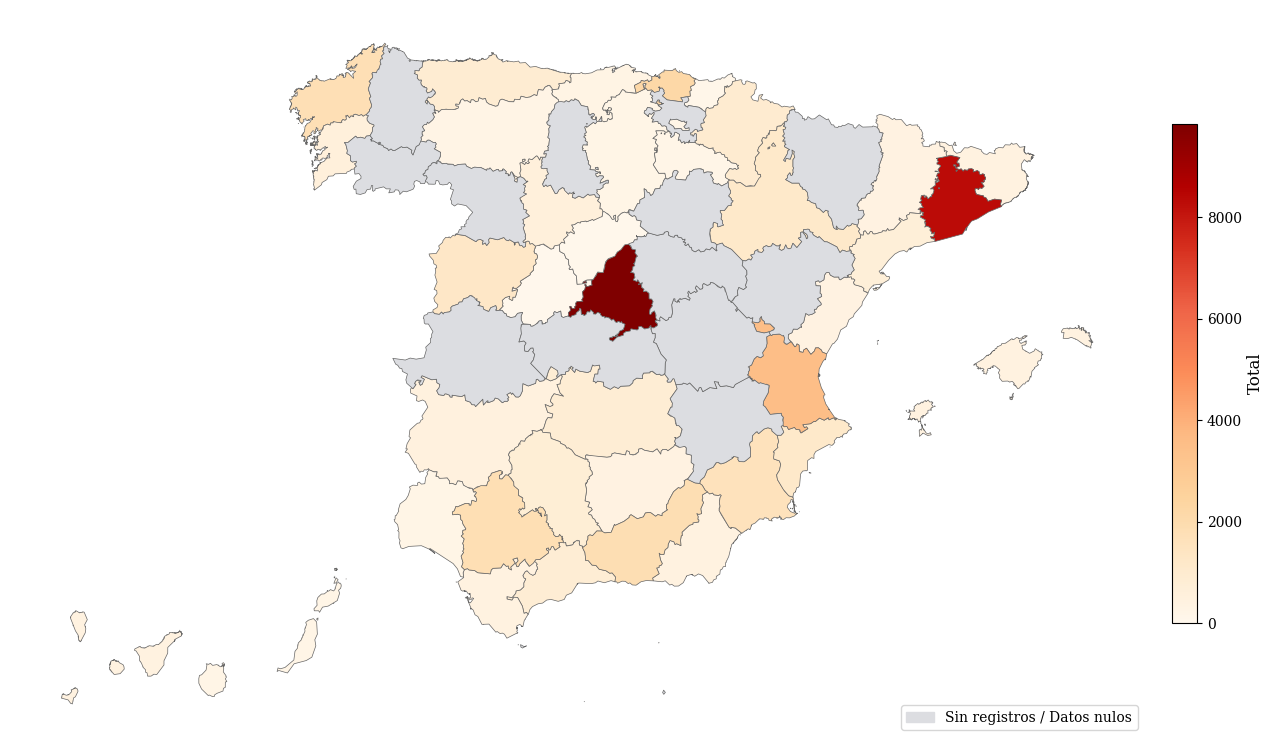

In [70]:
from src.analysis.visuals import generar_mapa
import geopandas as gpd
# --- EJEMPLO DE USO ---
# Supongamos que tu DF se llama 'df_egresados' y la columna de valor 'Total'
# generar_mapa_egresados(gdf_provinces, df_egresados, 'cod_ine', 'Total')
#url_geojson_ccaa = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-communities.geojson"
#gdf = gpd.read_file(url_geojson_ccaa)
url_geojson_provinces = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson"
gdf_provinces = gpd.read_file(url_geojson_provinces)
generar_mapa(gdf_provinces, provincia_grados_df, 'cpro', 'Total')
generar_mapa(gdf_provinces, provincia_masteres_df, 'cpro', 'Total')
generar_mapa(gdf_provinces, provincia_doctorados_df, 'cpro', 'Total')